# Competitor price tracker: the numbers

Every number on the project card and in the README comes from this notebook. It reads the
warehouse after the weekly runs: start the stack (`docker compose up -d`), let the
`competitor_prices` DAG catch up, then run this notebook top to bottom.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from config import load_config  # noqa: E402  every client value comes from config/client.yaml and .env

cfg = load_config()
w = cfg["warehouse"]
conn = psycopg.connect(host=w["host"], port=w["port"], dbname=w["database"], user=w["user"], password=w["password"])
CLIENT, CURRENCY, TZ = cfg["client"]["name"], cfg["client"]["currency"], cfg["schedule"]["timezone"]
START = pd.Timestamp(cfg["schedule"]["start_date"]).tz_localize(TZ)  # the first weekly run's week


def query(sql, *params):
    with conn.cursor() as cur:
        cur.execute(sql, params)
        return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])


colours = cfg["report"]["colours"]
ACCENT, GREY, INK = colours["data"][0], colours["muted"], colours["text"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": colours["line"],
                     "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
                     "figure.dpi": 110, "savefig.bbox": "tight"})

## 1. What the tracker watches

A product is tracked when at least one competitor listing is matched to it and has a price.

In [2]:
catalogue = query("SELECT count(*) FROM product").iat[0, 0]
products = query("SELECT count(DISTINCT sku) FROM price_gap").iat[0, 0]
stores = query("SELECT count(DISTINCT store_id) FROM price_gap").iat[0, 0]
print(f"{products} of our {catalogue} products tracked, across {stores} competitor stores")

query("""
    SELECT s.kind AS store_kind, count(DISTINCT g.store_id) AS stores, count(DISTINCT g.sku) AS products,
           count(*) AS listings
    FROM price_gap g JOIN store s USING (store_id)
    GROUP BY s.kind ORDER BY s.kind
""")

356 of our 360 products tracked, across 10 competitor stores


,store_kind,stores,products,listings
0,grocery store,8,200,668
1,web shop,2,156,156


## 2. Price changes caught

A change is a day's price that differs from the listing's previous price (the `price_change`
view). Only changes on our products count.

In [3]:
changes = query("SELECT c.*, s.kind AS store_kind FROM price_change c JOIN store s USING (store_id)")
cuts, rises = (changes.new_price < changes.old_price).sum(), (changes.new_price > changes.old_price).sum()
print(f"{len(changes)} price changes on our products: {cuts} cuts, {rises} rises")
print(f"{changes.is_discounted.mean():.0%} of them were to a price marked as a promotion")
changes.groupby("store_kind").size().rename("changes")

127 price changes on our products: 52 cuts, 75 rises
61% of them were to a price marked as a promotion


store_kind
grocery store    127
Name: changes, dtype: int64

## 3. Each change caught by the first run that could see it

A change can only be seen once both of its prices are published. The weekly run whose window
holds the later of the two publish times is the first run that can catch it. The check below
recomputes that week for every change and compares it with the week that actually caught it.
On the schedule, a week's run fires when the week ends.

In [4]:
caught = query("""
    WITH d AS (
        SELECT store_id, listing_key, observed_on, price, published_at, run_week,
               lag(price) OVER w AS old_price, lag(published_at) OVER w AS old_published,
               lag(run_week) OVER w AS old_week
        FROM daily_price WHERE sku IS NOT NULL
        WINDOW w AS (PARTITION BY store_id, listing_key ORDER BY observed_on)
    )
    SELECT observed_on, greatest(published_at, old_published) AS readable_at,
           greatest(run_week, old_week) AS caught_week
    FROM d WHERE old_price IS NOT NULL AND price <> old_price
""")
week = pd.Timedelta(days=7)
readable_at = pd.to_datetime(caught.readable_at, utc=True).dt.tz_convert(TZ)
caught["first_possible_week"] = (START + (readable_at - START) // week * week).dt.date
caught["run_fired"] = pd.to_datetime(caught.caught_week).dt.tz_localize(TZ) + week
caught["days_published_to_alert"] = (caught.run_fired - readable_at).dt.total_seconds() / 86400
caught["days_shelf_to_alert"] = (caught.run_fired - pd.to_datetime(caught.observed_on).dt.tz_localize(TZ)).dt.days

in_first_run = (caught.first_possible_week == caught.caught_week).mean()
print(f"{len(caught)} changes, caught by the first run that could see them: {in_first_run:.0%}")
print(f"Published to alert: median {caught.days_published_to_alert.median():.1f} days, "
      f"longest {caught.days_published_to_alert.max():.1f} days (one weekly run)")
print(f"Shelf date to alert: median {caught.days_shelf_to_alert.median():.0f} days "
      "(mostly the time shoppers take to upload a price)")

127 changes, caught by the first run that could see them: 100%


Published to alert: median 2.8 days, longest 7.0 days (one weekly run)
Shelf date to alert: median 5 days (mostly the time shoppers take to upload a price)


## 4. Undercuts and the alert

An undercut is a cut that takes a key product below our price. The weekly run emails the
undercuts it caught (only the latest run emails; the older weeks were loaded in one catch-up).

In [5]:
undercuts = query("SELECT * FROM undercut ORDER BY caught_week, product")
weeks = query("SELECT count(*) FROM generate_series(%s::date, (SELECT max(run_week) FROM price_observation), '7 days')",
              START.date()).iat[0, 0]
print(f"{len(undercuts)} undercuts on key products, in {undercuts.caught_week.nunique()} of {weeks} weekly runs")
print(query("SELECT * FROM alert_sent"))
undercuts.tail(10)

17 undercuts on key products, in 6 of 56 weekly runs
Empty DataFrame
Columns: [run_week, sent_at, undercuts]
Index: []


,caught_week,store,sku,product,observed_on,old_price,new_price,our_price
7,2026-02-01,Safeway (N Shoreline Blvd),GRO-0013,chocolate dark chocolate ice cream bars,2026-02-04,4.00,3.00,5.19
8,2026-02-01,Safeway (N Shoreline Blvd),GRO-0002,coffee almond toffee crunch ice cream bars,2026-02-04,4.00,3.00,4.29
9,2026-02-01,Safeway (N Shoreline Blvd),GRO-0014,dulce de leche ice cream,2026-02-04,4.00,3.00,7.09
10,2026-02-01,Safeway (N Shoreline Blvd),GRO-0004,Haagen dazs ice cream bars,2026-02-04,4.00,3.00,6.29
11,2026-02-01,Safeway (N Shoreline Blvd),GRO-0015,Pistachio Ice Cream,2026-02-04,4.00,3.00,7.49
12,2026-02-01,Safeway (N Shoreline Blvd),GRO-0003,vanilla bean ice cream,2026-02-04,4.00,3.00,4.89
13,2026-04-26,Safeway (San Antonio Rd),GRO-0014,dulce de leche ice cream,2026-05-01,3.50,2.99,7.09
14,2026-04-26,Safeway (San Antonio Rd),GRO-0003,vanilla bean ice cream,2026-05-01,3.50,2.99,4.89
15,2026-05-24,Walmart Supercenter,GRO-0023,Butter Pecan Ice Cream,2026-05-29,4.58,3.87,6.09
16,2026-08-02,Smart & Final extra!,GRO-0011,Medium Roast,2026-07-30,11.99,10.99,11.49


## 5. Matching

Grocery listings match on barcode. Web shop listings have no barcodes, so they match on the
product name, and our catalogue names products its own way. The optional answer file
(`inputs.match_truth`) holds the right listing for some products, to score the matching.

In [6]:
truth_path = cfg["input_dir"] / (cfg["inputs"].get("match_truth") or "-")
if truth_path.is_file():
    truth = pd.read_csv(truth_path)
    found = query("SELECT store_id, listing_key, sku FROM listing JOIN store USING (store_id) "
                  "WHERE source = 'web shop pages' AND sku IS NOT NULL")
    both = truth.merge(found, on=["store_id", "listing_key"], how="outer", suffixes=("_true", "_found"))
    correct = (both.sku_true == both.sku_found).sum()
    wrong = (both.sku_found.notna() & (both.sku_true != both.sku_found)).sum()
    missed = (both.sku_true.notna() & (both.sku_true != both.sku_found)).sum()
    print(f"Web shops, by name: {correct} of {len(truth)} matched correctly, {wrong} wrong, {missed} missed")
else:
    print("No answer file (inputs.match_truth): the name matching is not scored")

grocery = query("SELECT count(*) FILTER (WHERE barcode IS NOT NULL) AS ours, "
                "count(*) FILTER (WHERE barcode IS NOT NULL AND sku IN (SELECT sku FROM listing)) AS found "
                "FROM product")
print(f"Grocery, by barcode: {grocery.found[0]} of our {grocery.ours[0]} grocery products found at a competitor")

Web shops, by name: 156 of 160 matched correctly, 0 wrong, 4 missed
Grocery, by barcode: 200 of our 200 grocery products found at a competitor


## 6. Where we stand: price gaps

Each listing's latest price against ours. A negative gap means the competitor is cheaper.

64% of all listings are cheaper than us


,,listings,cheaper_than_us,average_gap_pct
store,kind,,,
Web Scraper test shop,web shop,60,0.283,1.556667
Books to Scrape,web shop,96,0.510,-0.478125
Ava's Market and Deli,grocery store,72,0.556,-4.036111
Nob Hill Foods,grocery store,153,0.582,-2.628105
99 Ranch Market,grocery store,21,0.619,1.590476
Safeway (N Shoreline Blvd),grocery store,187,0.674,-13.737968
Safeway (San Antonio Rd),grocery store,136,0.794,-15.756618
Smart & Final extra!,grocery store,57,0.825,-14.194737
Walmart Supercenter,grocery store,41,0.878,-14.04878


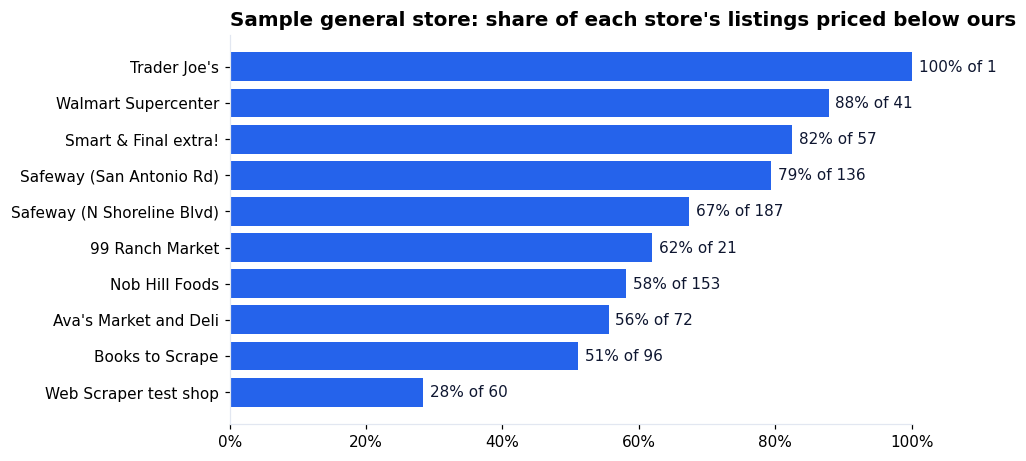

In [7]:
gaps = query("SELECT s.name AS store, s.kind, g.gap_pct FROM price_gap g JOIN store s USING (store_id)")
by_store = (gaps.groupby(["store", "kind"])
            .agg(listings=("gap_pct", "size"), cheaper_than_us=("gap_pct", lambda g: (g < 0).mean()),
                 average_gap_pct=("gap_pct", "mean"))
            .sort_values("cheaper_than_us"))
print(f"{(gaps.gap_pct < 0).mean():.0%} of all listings are cheaper than us")

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh([s for s, _ in by_store.index], by_store.cheaper_than_us, color=ACCENT)
for y, (share, n) in enumerate(zip(by_store.cheaper_than_us, by_store.listings)):
    ax.text(share + 0.01, y, f"{share:.0%} of {n}", va="center", color=INK)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title(f"{CLIENT}: share of each store's listings priced below ours")
fig.savefig(ROOT / "docs" / "gap-by-store.png")
by_store.round(3)

## 7. Changes per weekly run

kind
cuts     52
rises    75
dtype: int64

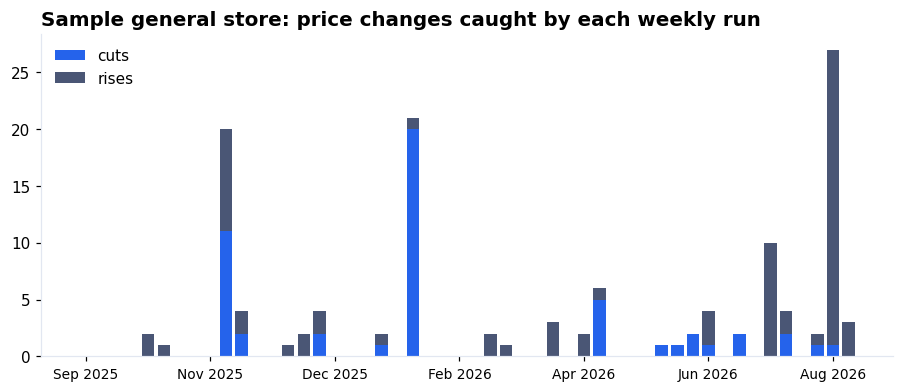

In [8]:
per_week = (changes.assign(kind=lambda c: (c.new_price < c.old_price).map({True: "cuts", False: "rises"}))
            .pivot_table(index="caught_week", columns="kind", values="sku", aggfunc="size", fill_value=0))
per_week = per_week.reindex(pd.date_range(START.date(), per_week.index.max(), freq="7D").date, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(range(len(per_week)), per_week.cuts, color=ACCENT, label="cuts")
ax.bar(range(len(per_week)), per_week.rises, bottom=per_week.cuts, color=GREY, label="rises")
ticks = range(0, len(per_week), 8)
ax.set_xticks(list(ticks), [per_week.index[i].strftime("%b %Y") for i in ticks], fontsize=9)
ax.set_title(f"{CLIENT}: price changes caught by each weekly run")
ax.legend(frameon=False)
fig.savefig(ROOT / "docs" / "changes-per-week.png")
per_week.sum()

## 8. One product at one competitor

Of the key products a competitor undercut, the one with the longest price history at that
store: the competitor's price over time against ours, with each undercut the run alerted on.

Original Sichuan Chili Crisp (GRO-0001) at Walmart Supercenter: 7 daily prices, 1 undercuts


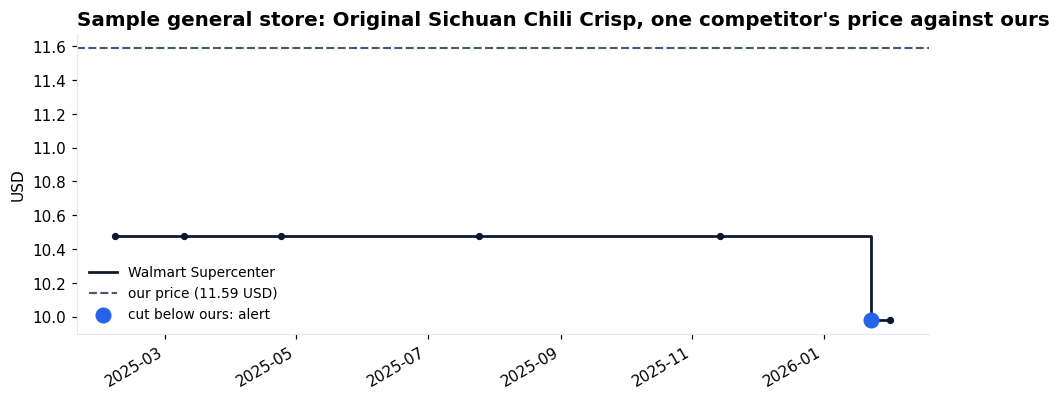

In [9]:
if undercuts.empty:
    print("No undercut yet, so no price history to show")
else:
    history_length = query("SELECT d.sku, s.name AS store, count(*) AS prices FROM daily_price d "
                           "JOIN store s USING (store_id) GROUP BY 1, 2")
    sku, store = (undercuts[["sku", "store"]].drop_duplicates().merge(history_length, on=["sku", "store"])
                  .sort_values(["prices", "sku"], ascending=[False, True]).iloc[0][["sku", "store"]])
    name, our_price = query("SELECT name, our_price FROM product WHERE sku = %s", sku).iloc[0]
    history = query("SELECT d.observed_on, d.price FROM daily_price d JOIN store s USING (store_id) "
                    "WHERE d.sku = %s AND s.name = %s ORDER BY d.observed_on", sku, store)
    marks = undercuts[(undercuts.sku == sku) & (undercuts.store == store)]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.step(history.observed_on, history.price, where="post", color=INK, linewidth=1.8, label=f"{store}")
    ax.scatter(history.observed_on, history.price, color=INK, s=14, zorder=2)
    ax.axhline(float(our_price), color=GREY, linestyle="--", linewidth=1.4, label=f"our price ({our_price} {CURRENCY})")
    ax.scatter(marks.observed_on, marks.new_price, color=ACCENT, s=90, zorder=3, label="cut below ours: alert")
    ax.set_title(f"{CLIENT}: {name}, one competitor's price against ours")
    ax.set_ylabel(CURRENCY)
    fig.autofmt_xdate()  # tilted dates stay readable on a short history
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(ROOT / "docs" / "price-history.png")
    print(f"{name} ({sku}) at {store}: {len(history)} daily prices, {len(marks)} undercuts")

## 9. The card's numbers

In [10]:
print(f"Title:  Knowing every competitor price change on {products} products, every week")
print(f"Result: {products} products across {stores} stores: {len(changes)} price changes caught, "
      f"each within one run ({in_first_run:.0%} caught by the first run that could see it).")

Title:  Knowing every competitor price change on 356 products, every week
Result: 356 products across 10 stores: 127 price changes caught, each within one run (100% caught by the first run that could see it).
